# 03_集成算法-LightGBM

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊集成学习中，另外一个重要的模型：LightGBM\~

在开始讲 LightGBM 之前，先把几个关键词捋清楚：

1. **集成算法（Ensemble）**：集成算法就像请一群不同的人一起出主意，最后把大家的意见综合起来，往往比单独听一个人的想法更靠谱。机器学习里也是：把很多“弱”模型（弱学习器）凑在一起，组合成一个“强”模型，预测效果更好。
2. **Boosting（提升）**：是一种“接力赛”式的集成方法：第一棵小树（弱模型）先上场，尽力把训练数据学一遍；第二棵小树看第一棵学得哪里不够好（哪里犯了错误），专门去纠正它；第三棵再去修正前两棵没做好的一块……一棵接一棵，最后把它们“加权”组合，整体表现就很强了。

那么，什么是LightGBM？

**LightGBM**（Light Gradient Boosting Machine），顾名思义，就是「轻量级的梯度提升机」。

它也是基于 Boosting（提升）的思想，用一棵棵“决策树”来做接力赛，但在速度和内存上做了很多优化。

**为什么要用 LightGBM？**

1. **训练速度快**

   - 传统的梯度提升树（比如 XGBoost）要遍历所有特征来找最佳分裂点，数据多、特征多就慢。
   - LightGBM 先把连续数值型特征分箱（binning）成直方图，用直方图来找分裂点，速度提升很多。
2. **内存占用低**

   - 分箱后数据变成整数（每个样本只记一个箱号），比原始浮点数更省空间。
3. **更高的准确率**

   - 它采用**Leaf-wise（叶子优先）**生长策略：每次都在当前所有叶子中选出「能让损失减少最多」的那个叶子去分裂，而不是像传统算法那样按层（Level-wise）分裂。
   - 这样做虽然可能会让树长得更深、更不平衡，但整体误差下降更快，模型更强。
4. **支持大规模数据 & 类别特征**

   - 对超大规模数据也能跑；对类别特征（categorical）可以直接处理，不用手动做 One-Hot 编码。

## 原理详解

这里给出 LightGBM（基于梯度提升树）的数学原理、公式推导及完整算法流程。

### 问题与目标函数

**1. 监督学习框架**

给定训练集 $\{(x_i, y_i)\}_{i=1}^n$，我们要学习一个模型 $F(x)$，使得对某种损失函数 $L(y, \hat y)$ 的经验风险最小化，并加上正则化项：


$$
\mathcal{L}(F) = \sum_{i=1}^n L\bigl(y_i, F(x_i)\bigr) + \sum_{k=1}^K \Omega(f_k),
$$


其中模型 $F$ 是由 $K$ 棵树 $f_k$ 组成的加法模型：


$$
F(x) = \sum_{k=1}^K f_k(x),\quad f_k \in \mathcal{F},
$$


$\mathcal{F}$ 表示回归树的函数空间。

**2. 树的正则化**

对单棵树 $f$ 的复杂度定义为


$$
\Omega(f) = \gamma T + \tfrac12 \lambda \sum_{j=1}^T w_j^2,
$$


$T$ 是树的叶子数；

$w_j$ 是第 $j$ 片叶子的权重（输出值）；

$\gamma$ 和 $\lambda$ 是超参数，用于控制树的大小和叶权重的范数。

### 二阶泰勒展开与梯度直方图

直接优化 $\mathcal{L}(F)$ 很难，LightGBM 采用梯度提升（Gradient Boosting）的逐步添加思想。在第 $m$ 步时，模型为


$$
F_{m-1}(x) = \sum_{k=1}^{m-1} f_k(x),
$$


要新增一棵树 $f_m$，使得总目标最小：


$$
\mathcal{L}^{(m)} = \sum_{i=1}^n L\bigl(y_i, F_{m-1}(x_i) + f_m(x_i)\bigr) + \Omega(f_m) + \text{常数}.
$$


对 $f_m$ 作二阶泰勒展开：


$$
L\bigl(y_i, F_{m-1}(x_i) + f_m(x_i)\bigr)\approx L(y_i, \hat y_i^{(m-1)}) + g_i f_m(x_i) + \tfrac12 h_i [f_m(x_i)]^2,
$$


其中


$$
g_i = \left.\frac{\partial L(y_i, \hat y)}{\partial \hat y}\right|_{\hat y=\hat y_i^{(m-1)}},\quad h_i = \left.\frac{\partial^2 L(y_i, \hat y)}{\partial \hat y^2}\right|_{\hat y=\hat y_i^{(m-1)}}.
$$


因此，去掉常数项，优化目标变为


$$
\tilde{\mathcal{L}}^{(m)} = \sum_{i=1}^n \bigl[g_i f_m(x_i) + \tfrac12 h_i f_m(x_i)^2\bigr] + \Omega(f_m).
$$


### 单棵树的最优叶权重与分裂增益

#### 最优叶权重

假设当前树 $f_m$ 有 $T$ 片叶子，第 $j$ 片叶子对应的样本集合为 $I_j$，并令该叶子的输出值为常数 $w_j$。

则：


$$
\sum_{i=1}^n \bigl[g_i f_m(x_i) + \tfrac12 h_i f_m(x_i)^2\bigr]= \sum_{j=1}^T \sum_{i\in I_j} \bigl[g_i w_j + \tfrac12 h_i w_j^2\bigr]= \sum_{j=1}^T \bigl[G_j w_j + \tfrac12 H_j w_j^2\bigr],
$$


其中


$$
G_j = \sum_{i\in I_j} g_i,\quad H_j = \sum_{i\in I_j} h_i.
$$


加上正则化 $\Omega$，对每个 $w_j$ 求导并令导数为零，得到最优解


$$
w_j^* = -\frac{G_j}{H_j + \lambda}.
$$


将其代回，可得该棵树的最优目标值（负的“分裂增益”）：


$$
\mathcal{L}^*_j = -\tfrac12 \frac{G_j^2}{H_j + \lambda} + \gamma.
$$


#### 分裂增益（Gain）

在某个节点上，如果把样本集 $I$ 按某特征某阈值分为左右两部分 $I_L$ 和 $I_R$，则分裂带来的增益为


$$
\text{Gain} = \tfrac12\Bigl(\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda}\Bigr) - \gamma.
$$


$G_L, H_L$：左子集的梯度和二阶导和；

$G_R, H_R$：右子集的梯度和二阶导和；

$\gamma$：分裂的惩罚，避免过度分裂。

算法在所有候选特征和候选分裂点上计算 Gain，选择最大的那个进行真正分裂。

### 直方图优化与 Leaf-wise 策略

1. **直方图分箱（Histogram Binning）**

   - 对每个连续特征，先将取值域划分为 $B$ 个箱（bins），样本只记录箱编号。
   - 这样在寻找分裂点时，不再按样本逐一扫描，而是按箱聚合：每个箱维护 $\sum g_i$ 和 $\sum h_i$，速度和内存占用大幅下降。
2. **Leaf-wise 生长**

   - 传统 GBDT（如 XGBoost）的 Level-wise：逐层对所有叶子同时分裂；
   - LightGBM 的 Leaf-wise：每一步只挑一个叶子（当前所有叶子中 Gain 最大的）进行分裂，直到满足最大叶数或最小增益阈值。
   - 优点：更快降低损失；缺点：生成的树可能更不平衡、更深，需要通过 `max_depth`、`min_data_in_leaf` 控制。

---

### 完整算法流程（伪代码）

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
输入：训练集 {(x_i, y_i)}, 迭代次数 M, 学习率 η, 树参数 (max_leaves, λ, γ, min_gain_to_split, …)
初始化：F_0(x) = argmin_c ∑_i L(y_i, c)    // 常数预测

for m = 1 … M:
    1. 计算当前预测 F_{m-1}(x_i)，以及梯度 g_i 和二阶导 h_i
    2. 构建一棵新树 f_m：
       a. 初始化只有一个叶子的树，样本集合 I = {1…n}
       b. 维护一个“候选叶子列表”，初始为根节点
       c. while 树叶子数 < max_leaves:
            i. 对候选叶子 j，按直方图计算所有特征所有分裂点的 Gain_j
           ii. 找到全局最大的 Gain*，对应叶子 j* 和分裂点 s*
          iii. 若 Gain* < min_gain_to_split: break
           iv. 在叶子 j* 上按 s* 分裂成左右叶子，更新候选叶子列表
       d. 对所有叶子 j，计算最优权重 w_j* = –G_j/(H_j+λ)
    3. 更新模型：F_m(x) = F_{m-1}(x) + η · f_m(x)

输出：最终模型 F_M(x)
```

总结一下：

- **核心思想**：用梯度和二阶导信息做二阶泰勒近似，快速计算最优叶权重和分裂增益；
- **性能优化**：直方图分箱减少计算量，Leaf-wise 策略快速降低损失；
- **正则化**：通过 $\lambda$ 和 $\gamma$ 控制叶权重和树的复杂度，防止过拟合；
- **可控性**：多种超参数（如 `max_leaves`、`min_data_in_leaf`、`learning_rate`）让你在速度、内存、准确率之间灵活权衡。

## 完整案例

咱们通过一个**加州房价预测**的实际案例，详细演示如何使用 LightGBM 进行回归任务，从数据加载、预处理、模型训练、评估，到可视化分析、超参数调优和算法优化，全流程展开。

在房价预测、广告点击率预估、信用风险评估等场景中，往往需要处理海量数据并给出高精度的数值预测。LightGBM 以其训练速度快、内存占用低、准确率高等优点，被广泛应用于工业界。

本案例选用 **California Housing**（加州房价）数据集，包含约 20000 条样本，8 个数值型特征，目标是预测房屋中位价（单位：10 万美元）。

整体步骤：

1. 加载并简单探索数据
2. 划分训练/测试集
3. 训练初始 LightGBM 模型并评估性能
4. 可视化分析：特征重要性、预测 vs 实际 散点图
5. 超参数调优（Grid Search）
6. 训练优化后模型，比较性能差异
7. 总结与心得

### 数据加载

In [2]:
import pandas as pd
import numpy as np
from notebook_support import load_local_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

# 1. 加载加州房价数据集
data = load_local_housing(as_frame=True)
X = data.data             # 特征：8 个数值列
y = data.target           # 目标：房价中位数（单位：10 万美元）

# 2. 划分训练集和测试集（80% / 20%）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. 初始模型训练
model_initial = LGBMRegressor(
    objective='regression',
    random_state=42
, n_jobs=1, verbosity=-1)
model_initial.fit(X_train, y_train)

# 4. 初始模型评估
y_pred_initial = model_initial.predict(X_test)
rmse_initial = np.sqrt(mean_squared_error(y_test, y_pred_initial))
mae_initial  = mean_absolute_error(y_test, y_pred_initial)
r2_initial   = r2_score(y_test, y_pred_initial)
print(f"Initial RMSE: {rmse_initial:.4f}")
print(f"Initial MAE : {mae_initial:.4f}")
print(f"Initial R2  : {r2_initial:.4f}")

Initial RMSE: 0.5635
Initial MAE : 0.3805
Initial R2  : 0.7474


运行上述代码后，控制台会输出初始模型在测试集上的 **RMSE**, **MAE**, **R²**。这三项指标分别衡量预测误差的平方根、绝对误差平均值和拟合优度，数值越低（或 R² 越接近 1）代表效果越好。

### 可视化分析

#### 特征重要性

LightGBM 内部可以直接给出各特征的重要性排序。我们画出水平条形图，颜色易区分。

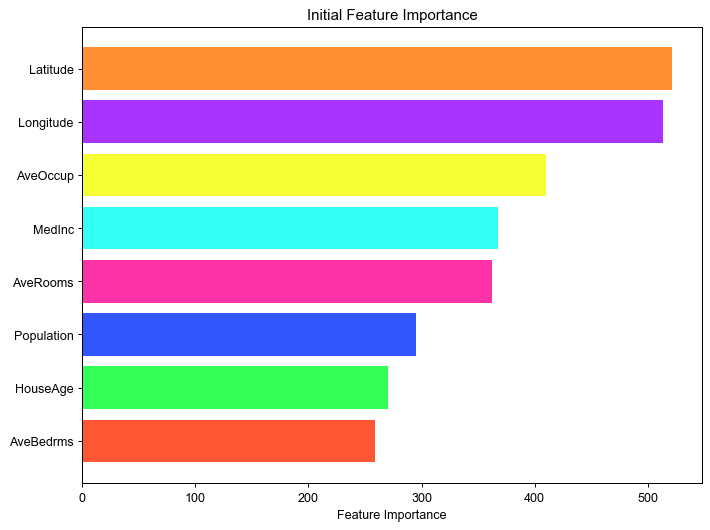

In [3]:
# 5. 特征重要性可视化
importances = model_initial.feature_importances_
features    = X.columns
indices     = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(
    features[indices],
    importances[indices],
    color=['#FF5733','#33FF57','#3357FF','#FF33A8',
           '#33FFF5','#F5FF33','#A833FF','#FF8F33']
)
plt.xlabel("Feature Importance")
plt.title("Initial Feature Importance")
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_039.png)

- 横坐标表示某特征在所有决策树分裂时的累计“重要性”得分，数值越高说明该特征对模型贡献越大。
- 通过此图，可以快速识别最关键的几项输入特征，为后续的特征工程或降维提供依据。

#### 预测值 vs 实际值

通过散点图直观对比预测值与真实值，理想情况是点都分布在对角线附近。

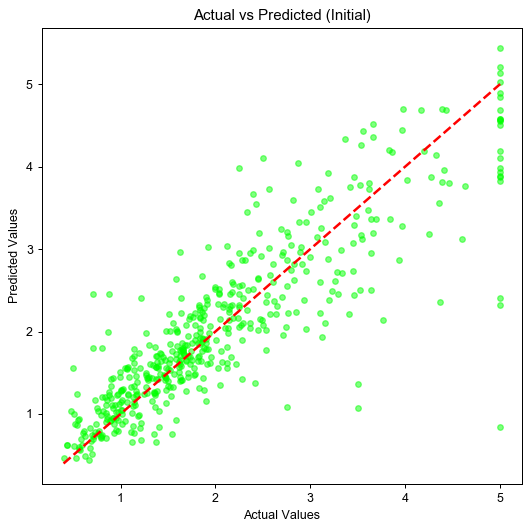

In [4]:
# 6. 预测值 vs 实际值 散点图
plt.figure(figsize=(6, 6))
plt.scatter(
    y_test, y_pred_initial,
    alpha=0.5, s=20, color='lime'
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Initial)")
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_040.png)

- 绿色散点表示每个样本的真实房价 vs 预测房价。
- 红色虚线是理想对角线，点越接近此线，说明预测越准确。
- 散点分布的离散程度和是否存在系统性偏差（如高房价低估）都能一目了然。

### 算法优化：超参数调优

虽然 LightGBM 默认参数就已经较好，但通过有针对性的网格搜索（Grid Search）可以进一步提升模型性能。

下面针对 `n_estimators`、`num_leaves`、`learning_rate`、`max_depth` 四个关键参数进行 5 折交叉验证。

In [5]:
# 7. 超参数调优
param_grid = {
    'n_estimators'   : [100, 200],
    'num_leaves'     : [31, 50],
    'learning_rate'  : [0.1, 0.05],
    'max_depth'      : [-1, 10]
}
grid = GridSearchCV(
    estimator=LGBMRegressor(random_state=42, n_jobs=1, verbosity=-1),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1,
    verbose=2
, error_score='raise')
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=31; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=31; total time=   0.0s


[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=31; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=31; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=31; total time=   0.0s


[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=50; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=50; total time=   0.0s


[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=50; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=50; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=-1, n_estimators=100, num_leaves=50; total time=   0.0s


[CV] END learning_rate=0.1, max_depth=-1, n_estimators=200, num_leaves=31; total time=   0.1s


...

[CV] END learning_rate=0.05, max_depth=10, n_estimators=200, num_leaves=31; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=200, num_leaves=31; total time=   0.1s


[CV] END learning_rate=0.05, max_depth=10, n_estimators=200, num_leaves=31; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=200, num_leaves=31; total time=   0.1s


[CV] END learning_rate=0.05, max_depth=10, n_estimators=200, num_leaves=50; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=200, num_leaves=50; total time=   0.1s


[CV] END learning_rate=0.05, max_depth=10, n_estimators=200, num_leaves=50; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=200, num_leaves=50; total time=   0.1s


[CV] END learning_rate=0.05, max_depth=10, n_estimators=200, num_leaves=50; total time=   0.1s
Best Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}


> **调优思路**：

- **n_estimators**：迭代树的棵数，越多可能拟合越充分，但训练越慢且易过拟合。
- **num_leaves**：每棵树的最大叶子节点数，控制树的复杂度；数值越大，模型越灵活，但过大会过拟合。
- **learning_rate**：学习率，控制每棵树对最终结果的贡献；越小需要更多迭代，但更易收敛到更优解。
- **max_depth**：树的最大深度，防止树过深；`-1` 表示不限制深度。

网格搜索会输出一组最优参数，例如：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
Best Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'num_leaves': 50}
```

### 优化后模型训练与评估

使用调优后的最优参数重新训练模型，并评估性能：

In [6]:
# 8. 优化后模型评估
model_opt = grid.best_estimator_
y_pred_opt = model_opt.predict(X_test)

rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
mae_opt  = mean_absolute_error(y_test, y_pred_opt)
r2_opt   = r2_score(y_test, y_pred_opt)

print(f"Optimized RMSE: {rmse_opt:.4f}")
print(f"Optimized MAE : {mae_opt:.4f}")
print(f"Optimized R2  : {r2_opt:.4f}")

Optimized RMSE: 0.5679
Optimized MAE : 0.3807
Optimized R2  : 0.7435


- **RMSE**、**MAE** 越低越好，**R²** 越接近 1 越好。
- 与初始模型相比，如果调优有效，应能看到 RMSE/MAE 的下降以及 R² 的提升。

#### 性能对比柱状图

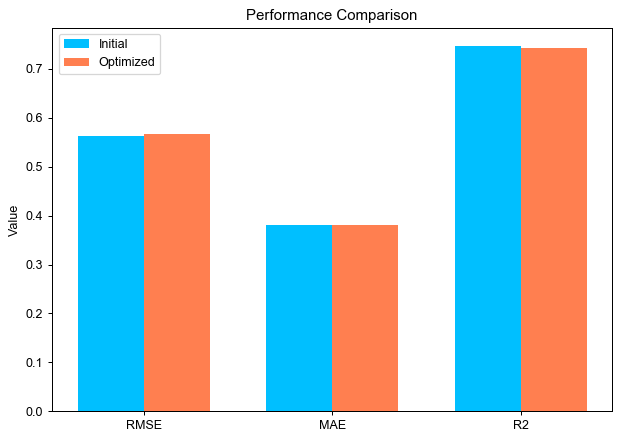

In [7]:
# 9. 性能对比柱状图
metrics      = ['RMSE', 'MAE', 'R2']
initial_vals = [rmse_initial, mae_initial, r2_initial]
opt_vals     = [rmse_opt,    mae_opt,    r2_opt]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(
    x - width/2,
    initial_vals,
    width,
    label='Initial',
    color='deepskyblue'
)
plt.bar(
    x + width/2,
    opt_vals,
    width,
    label='Optimized',
    color='coral'
)
plt.xticks(x, metrics)  
plt.ylabel("Value")
plt.title("Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_041.png)

- 该柱状图直观展示了初始模型与优化后模型在三种指标上的差异。
- 如果橙色（Optimized）的 RMSE 和 MAE 条明显低于蓝色（Initial），且 R² 明显更高，则说明调优取得了显著效果。

本案例使用 LightGBM 在加州房价数据集上完成了从**初始模型**到**可视化分析**、**超参数调优**、**优化后模型评估**的完整流程。

## 模型分析

### LightGBM 模型的优缺点

**优点：**

1. **训练速度快、内存占用低**LightGBM 使用直方图分箱技术将连续特征离散化，从而减少计算量和内存使用。同时，其采用叶子优先（leaf-wise）的生长策略，能更快地降低训练误差，在大规模数据集上表现尤为突出。
2. **高精度与优秀的泛化能力**：通过二阶泰勒展开，利用梯度和 Hessian 信息，LightGBM 可以更准确地计算分裂增益，从而建立更精准的模型。正则化机制（如叶子权重的 L2 正则化、分裂惩罚 γ 等）帮助防止过拟合。
3. **对大规模数据和高维数据的良好支持**：LightGBM 可以高效处理上亿条记录的数据，并且能够直接处理类别特征（无需手动做 One-Hot 编码），适用于工业级应用场景。
4. **良好的可扩展性与灵活性**：其丰富的超参数调控机制（例如 num_leaves、max_depth、feature_fraction 等）使得用户可以根据不同的数据特征和业务需求进行细致调优，达到较优的预测效果。

**缺点：**

1. **树结构不平衡可能导致过拟合风险**：由于采用叶子优先的策略，生成的树结构往往比较不平衡，部分情况下会造成过拟合，尤其是在数据量较小或噪声较多时。因此需要借助 max_depth、min_data_in_leaf 等参数来限制树的深度和叶子的样本数。
2. **对类别特征处理较为敏感**：虽然 LightGBM 内部能直接处理类别特征，但在类别特征取值较多或类别间分布不平衡时，可能出现信息利用不足的情况，导致模型效果下降。这时可能需要结合特征工程进一步处理类别特征。
3. **调参过程相对复杂**：由于 LightGBM 提供了较多超参数，调参时需要综合考虑多种指标（速度、准确率、泛化能力），对于初学者来说调参过程可能比较繁琐，且在数据规模大时，调参时间会相应增加。

### 与其他相似算法的对比

下表总结了 LightGBM 与常用的其他两种梯度提升算法（XGBoost 和 CatBoost）在多个关键维度上的比较：

| **算法** | **优点** | **缺点** |
|-|-|-|
| **LightGBM** | - 训练速度快、内存占用低  <br/>- 适合大规模、高维数据  <br/>- 内置直方图优化、支持类别特征直接处理 | - 生成的树可能不平衡，存在过拟合风险  <br/>- 对部分参数较为敏感，调参过程较复杂 |
| **XGBoost** | - 理论成熟，广泛使用  <br/>- 支持二阶梯度信息  <br/>- 模型解释性较好，调参较为稳定 | - 对大规模数据训练速度相对较慢  <br/>- 内存占用较高  <br/>- 在处理类别特征时需手动预处理（如 One-Hot 编码） |
| **CatBoost** | - 对类别特征处理能力强，无需额外预处理  <br/>- 内置均衡处理类别特征，降低过拟合风险 | - 训练速度一般较 LightGBM 略慢  <br/>- 模型调参选项较少，灵活性较低  <br/>- 在某些场景下精度可能略低于 XGBoost 或 LightGBM |

### 适用情况讨论

**适用 LightGBM 的情况：**

1. **大规模数据或高维数据场景**：当数据量特别大（如上亿条记录）或者特征维度较高时，LightGBM 的直方图分箱和叶子优先策略能显著提升训练速度和节省内存，适合用于工业级应用，例如广告点击率预估、推荐系统、金融风控等。
2. **对模型预测速度要求较高的场景**：由于 LightGBM 具有较快的训练和预测速度，因此在需要快速响应的实时预测系统中，它是一种理想选择。
3. **类别特征较多或分布较为离散的任务**：如果数据中存在大量类别特征，且希望尽量避免繁琐的预处理，LightGBM 能够直接处理类别特征（虽然要注意类别数过多时可能需要额外处理）。
4. **需要较高预测精度且能够进行充分调参的场景**：当项目允许花费时间进行超参数调优，从而取得更高的预测精度时，LightGBM 的灵活性和丰富的超参数调控手段能发挥较大优势。

**考虑其他算法的情况：**

1. **数据规模较小或特征较少**：在数据量较小的场景下，XGBoost 由于其模型结构较为平衡，可能更容易获得稳定的预测效果，同时调参过程也相对简单。另外，CatBoost 在处理少量类别特征时也表现不俗，因此在小数据场景下可以作为备选。
2. **对模型解释性要求较高的任务**：如果需要对模型做较详细的解释，XGBoost 的树结构相对更易解释，且其输出的特征重要性信息较为直观。在一些金融、医疗领域的风险评估任务中，这一点尤为重要。
3. **类别特征特别复杂且对类别特征处理要求较高**：当数据集中类别特征非常多且类别间分布不平衡时，CatBoost 内置的类别特征处理能力可能更强，可以避免手动预处理带来的麻烦，同时减少由于类别特征引起的偏差。
4. **对调参时间和资源要求较高的场景**：如果项目资源有限，调参时间和计算资源不足，XGBoost 和 CatBoost 的默认参数可能已经能取得较好效果，而 LightGBM 在调参时可能需要较多的实验和计算成本。

## 最后

- **LightGBM 的优势**主要体现在大规模数据处理、训练速度和内存占用方面，并且在精度上通过二阶泰勒展开和正则化手段能取得良好表现，适用于数据量大、特征复杂的实际业务场景。
- **不足之处**则包括树结构不平衡可能导致的过拟合风险、对类别特征的敏感性以及调参过程相对复杂的问题。
- 在与 XGBoost、CatBoost 的对比中，可以看出 LightGBM 更适合大数据量、高维度、实时性要求高的任务，而 XGBoost 适合需要更高模型解释性和稳定性的小数据场景，CatBoost 则在处理复杂类别特征时有天然优势。

因此，当项目中数据量非常大、实时性要求高且特征较多时，LightGBM 是首选；而在数据量较小、解释性要求较高或者类别特征处理复杂时，则可以考虑使用 XGBoost 或 CatBoost，甚至对多种算法进行融合，以达到更优的效果。